<a href="https://colab.research.google.com/github/mateist04/experience-classifier-svm/blob/main/employee_experience_pred_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experience Level Prediction from Salary Data

A machine learning pipeline leveraging Support Vector Machines (SVM) to classify employee experience levels. This project explores the non-linear relationships between compensation, job roles, and professional seniority using the Salary Insights dataset.

## Task 0: Import libraries ✅

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

## Task 1: Download Dataset 📃

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Columns explanations:

  **'work_year'** - Year of salary data

  **'experience_level'** - Employee seniority level

*   **EN**: Entry Level
*   **MI**: Mid Level
*   **SE**: Senior Level
*   **EX**: Executive Level

  **'employment_type'** - Full-time, part-time, contract, etc.

  **'salary'** - Salary amount (original currency)

  **'salary_in_usd'** - Salary conversion in USD currency

  **'remote_ratio'** - Percentage of remote work (0, 50, 100)

In [ ]:
import os
# Insert here your own path to the "Dataset salary 2024.csv" file
df = pd.read_csv("/content/drive/MyDrive/...")
df.head(5)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


## Task 2: Exploring the data 📃

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           16534 non-null  int64 
 1   experience_level    16534 non-null  object
 2   employment_type     16534 non-null  object
 3   job_title           16534 non-null  object
 4   salary              16534 non-null  int64 
 5   salary_currency     16534 non-null  object
 6   salary_in_usd       16534 non-null  int64 
 7   employee_residence  16534 non-null  object
 8   remote_ratio        16534 non-null  int64 
 9   company_location    16534 non-null  object
 10  company_size        16534 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.4+ MB


In [ ]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [ ]:
# unique entries in experience_level

print(df['experience_level'].unique())

['SE' 'MI' 'EN' 'EX']


In [ ]:
i = 0
for j in df['job_title'].unique():
  i += 1
print("Number of unique jobs:", i)

Number of unique jobs: 155


In [ ]:
for i in df.columns:
  print(i)
  print(df[i].unique())

work_year
[2024 2022 2023 2020 2021]
experience_level
['SE' 'MI' 'EN' 'EX']
employment_type
['FT' 'CT' 'PT' 'FL']
job_title
['AI Engineer' 'Data Engineer' 'Machine Learning Engineer' 'ML Engineer'
 'Data Analyst' 'NLP Engineer' 'Data Scientist' 'Applied Scientist'
 'Data Manager' 'Data Architect' 'Data Operations Manager'
 'Research Scientist' 'Data Science Manager'
 'Business Intelligence Engineer' 'Business Intelligence' 'Data Modeler'
 'Data Integration Specialist' 'Data Product Manager'
 'Data Visualization Specialist' 'Data Science' 'Data Specialist'
 'Business Intelligence Lead' 'Research Analyst'
 'Business Intelligence Analyst' 'AI Software Engineer'
 'Machine Learning Scientist' 'Data Science Engineer'
 'Machine Learning Operations Engineer' 'Analytics Engineer'
 'Data Management Analyst' 'Encounter Data Management Professional'
 'Data Analytics Specialist' 'Head of Data' 'Data Analytics Lead'
 'Research Engineer' 'AI Scientist' 'Business Intelligence Developer'
 'Machine Lear

##Exploratory data analysis:

The visualization below confirms a monotonic, near-linear relationship between the mean **'salary_in_usd'** and the **'experience_level'**, following the expected hierarchy: $\text{EN} < \text{MI} < \text{SE} < \text{EX}$. This suggests **'salary_in_usd'** will be a highly discriminative feature.

Text(0.5, 1.0, 'Average salary by experience level')

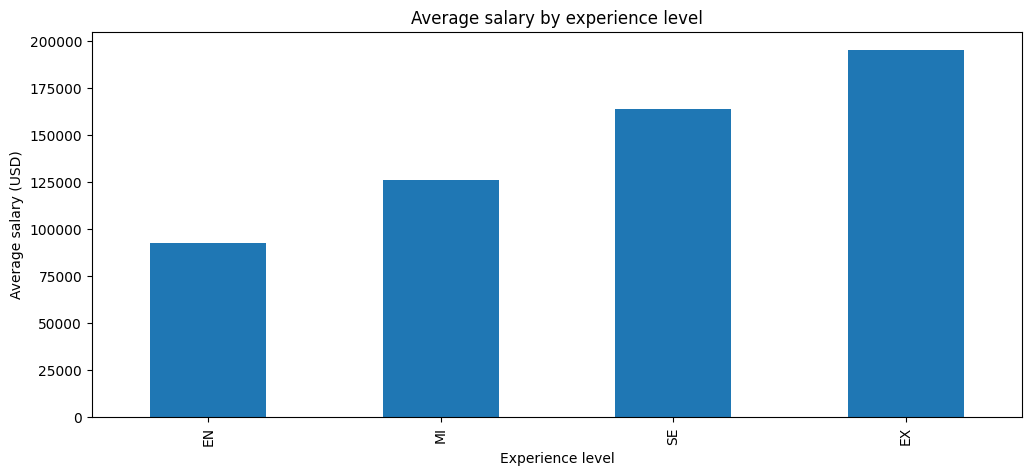

In [ ]:
order = ["EN", "MI", "SE", "EX"]

experience_salary_mean = (
    df.groupby("experience_level")["salary_in_usd"].mean().sort_index()
)

experience_salary_mean_ordered = experience_salary_mean.reindex(order)

experience_salary_mean_ordered.plot(kind='bar', figsize=(12, 5))
plt.xlabel('Experience level')
plt.ylabel('Average salary (USD)')
plt.title('Average salary by experience level')

Given the strong, anticipated correlation between higher **'salary_in_usd'** and higher **'experience_level'**, **'salary_in_usd'** feature is essential for model training.

In [ ]:
# print the number of samples for the target column
print(df['experience_level'].value_counts())

experience_level
SE    10670
MI     4038
EN     1325
EX      501
Name: count, dtype: int64


Text(0.5, 1.0, 'Histogram of experience levels')

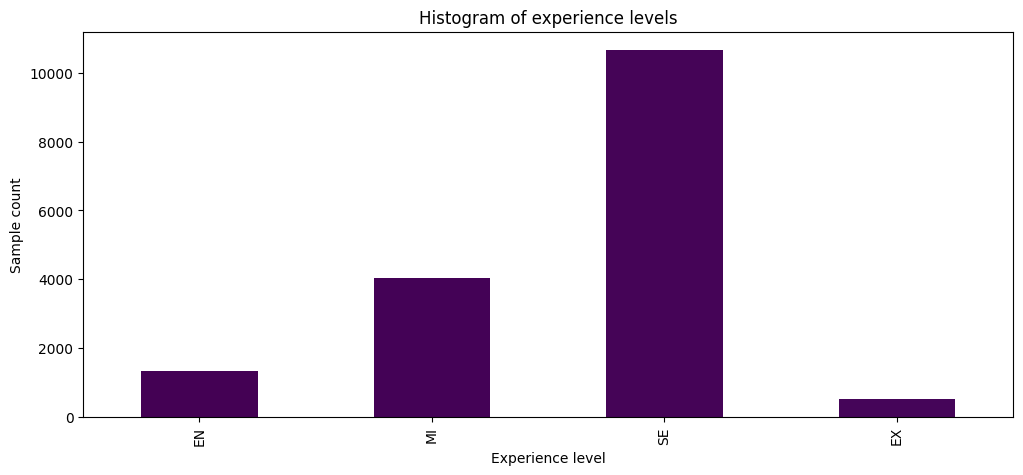

In [ ]:
order = ["EN", "MI", "SE", "EX"]

experience_level_count = (
    df.groupby("experience_level")["experience_level"].value_counts()
)

experience_level_count_ordered = experience_level_count.reindex(order)

colors = plt.cm.viridis(range(len(experience_level_count_ordered)))

experience_level_count_ordered.plot(kind='bar', color=colors, figsize=(12, 5))
plt.xlabel('Experience level')
plt.ylabel('Sample count')
plt.title('Histogram of experience levels')

**Model's Limitation**

Due to the extreme class imbalance dominated by the **SE** category (10,670 samples), the model's performance will involve a trade-off, limiting its ability to achieve high precision and recall for the minority classes with fewer observations (**EN**, **EX** and **MI**).

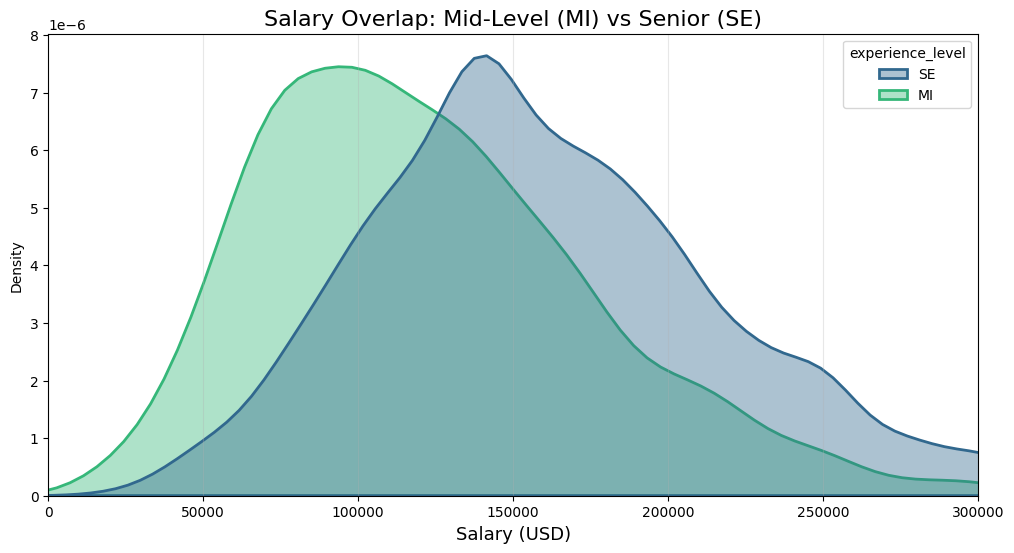

In [ ]:
import seaborn as sns

# filter the data to only include MI and SE
df_subset = df[df['experience_level'].isin(['MI', 'SE'])]

plt.figure(figsize=(12, 6))

# fill=True makes the overlap visible
# common_norm=False scales each independently so shapes can be compared even if counts differ
sns.kdeplot(data=df_subset, x='salary_in_usd', hue='experience_level',
            fill=True, common_norm=False, palette='viridis', alpha=0.4, linewidth=2)

plt.title('Salary Overlap: Mid-Level (MI) vs Senior (SE)', fontsize=16)
plt.xlabel('Salary (USD)', fontsize=13)
plt.xlim(0, 300000) # zoom in on the relevant range
plt.grid(axis='x', alpha=0.3)

plt.show()

This density plot confirms the difficulty of the task. The salary distributions for Mid-level and Senior roles have a significant overlap. A linear boundary cannot separate these two classes without high error. A problem which can be mitigated by using the RBF kernel to project these indistinct points into a higher-dimensional space.

In [ ]:
crosstab_company_size = pd.crosstab(df['experience_level'], df['company_size'])
print(crosstab_company_size)

company_size        L      M   S
experience_level                
EN                130   1143  52
EX                 23    470   8
MI                324   3644  70
SE                563  10049  58


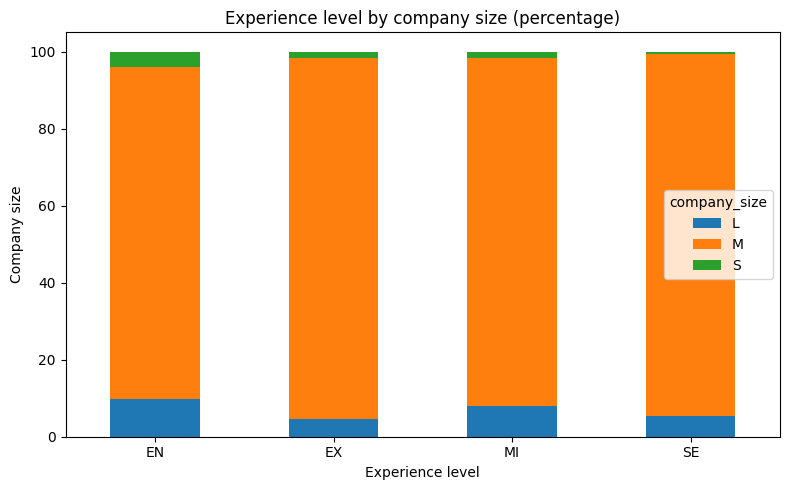

In [ ]:
crosstab_company_size_pct = crosstab_company_size.div(crosstab_company_size.sum(axis=1), axis=0) * 100

crosstab_company_size_pct.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.xlabel('Experience level')
plt.ylabel('Company size')
plt.title('Experience level by company size (percentage)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Assessing 'company_size' Relevance**

Although the **Medium** category is dominant, the presence of a considerable volume in the **Large** and **Small** categories prevents us from dismissing **'company_size'** as irrelevant based on marginal statistics alone. It will be retained to allow the SVM to learn potential non-linear differences in salary based on company scale.

In [ ]:
crosstab_employment_type = pd.crosstab(df['experience_level'], df['employment_type'])
print(crosstab_employment_type)

employment_type   CT  FL     FT  PT
experience_level                   
EN                 7   3   1287  28
EX                 1   0    500   0
MI                14   6   4011   7
SE                 6   5  10656   3


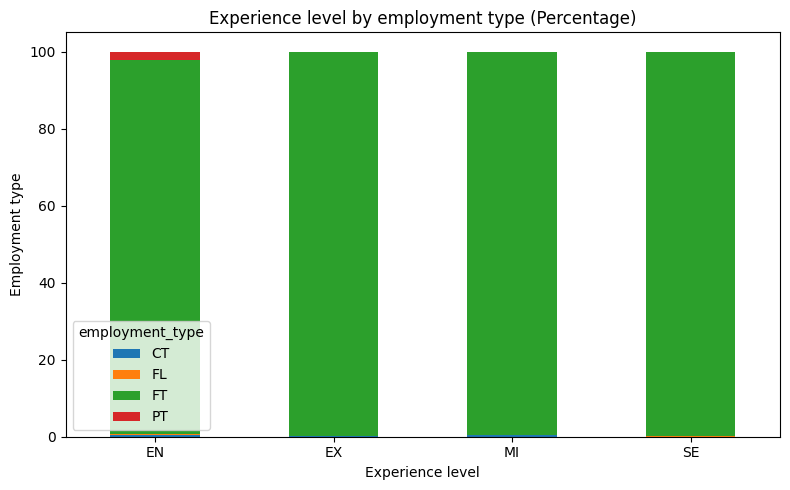

In [ ]:
crosstab_employment_type_pct = crosstab_employment_type.div(crosstab_employment_type.sum(axis=1), axis=0) * 100

crosstab_employment_type_pct.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.xlabel('Experience level')
plt.ylabel('Employment type')
plt.title('Experience level by employment type (Percentage)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The crosstab visualization clarifies that **'employment_type'** is unnecessary for the feature space because the dataset has a much significant proportion of full-time employees compared to other types of employment.

In [ ]:
job_counts = df['job_title'].value_counts()
print(job_counts)

job_title
Data Engineer                3464
Data Scientist               3314
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
                             ... 
BI Data Engineer                1
Marketing Data Engineer         1
Data Science Tech Lead          1
Principal Data Architect        1
Cloud Data Architect            1
Name: count, Length: 155, dtype: int64


In [ ]:
counts = df['job_title'].value_counts()
filtered_counts = counts[counts <= 10]
print(filtered_counts)

job_title
Business Intelligence Lead              10
Principal Data Scientist                10
Machine Learning Developer              10
Machine Learning Operations Engineer     9
Data Product Owner                       8
                                        ..
BI Data Engineer                         1
Marketing Data Engineer                  1
Data Science Tech Lead                   1
Principal Data Architect                 1
Cloud Data Architect                     1
Name: count, Length: 85, dtype: int64


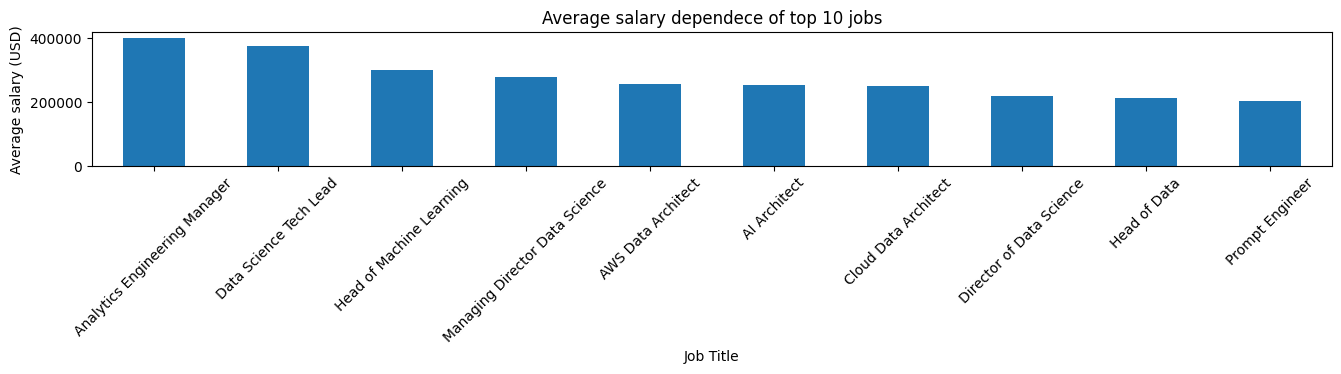

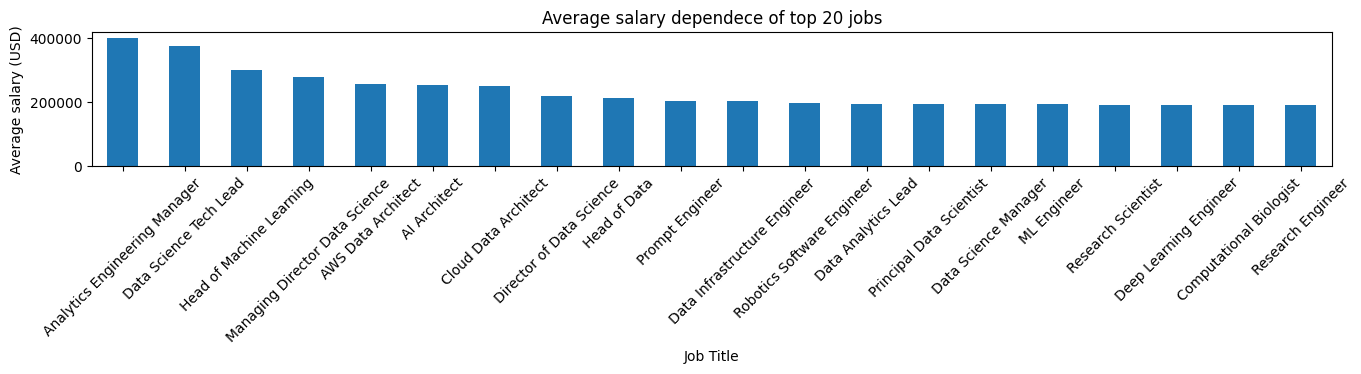

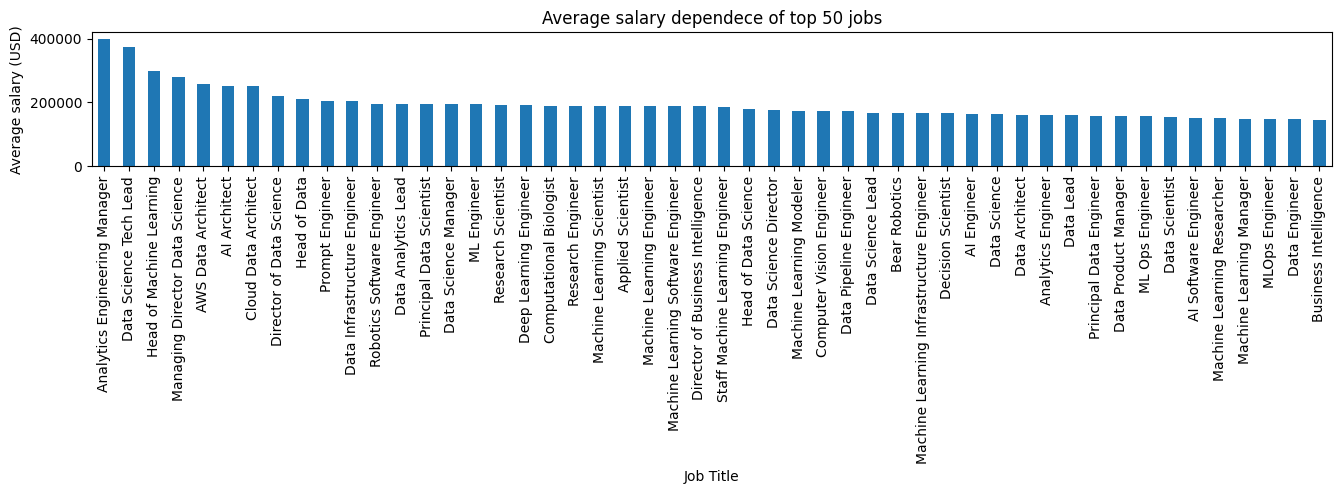

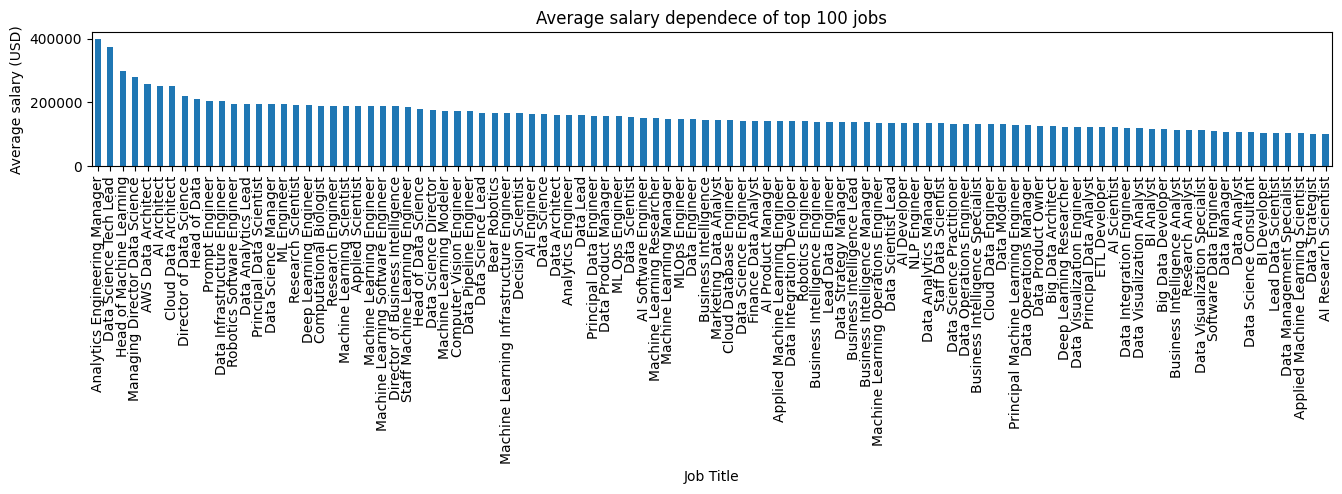

In [ ]:
job_salary_mean = (
    df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False)
)

top_jobs = [10, 20, 50, 100]

i = 1

for top_n in top_jobs:
  job_salary_top = job_salary_mean.head(top_n)

  plt.subplot(4, 1, i)
  job_salary_top.plot(kind='bar', figsize=(16, 8))
  plt.xlabel('Job Title')
  plt.ylabel('Average salary (USD)')
  plt.title(f"Average salary dependece of top {top_n} jobs")
  if i < 3:
    plt.xticks(rotation=45)
  else:
    plt.xticks(rotation=90)
  plt.show()
  i += 1


**Goal: Reduce Sparsity in 'job_title'**

The preliminary analysis shows that the **'job_title'** column has many unique values with very few samples. These rare categories introduce sparsity and noise that can hurt model performance increasing variance. To attenuate this, we will group all job titles with fewer than 10 samples into a single **'Other'** category.

**Creation of "job_title_categorized" feature:**

In [ ]:
# create a list with all job titles which have less than 11 samples
filtered_job_names = filtered_counts.index.tolist()
print(filtered_job_names)

['Business Intelligence Lead', 'Principal Data Scientist', 'Machine Learning Developer', 'Machine Learning Operations Engineer', 'Data Product Owner', 'Data Analytics Specialist', 'Robotics Software Engineer', 'Data Science Director', 'Data Analytics Consultant', 'Encounter Data Management Professional', 'AI Research Engineer', 'AI Programmer', 'Head of Machine Learning', 'Data Quality Manager', 'Data Operations Manager', 'Data Operations Associate', 'Business Intelligence Specialist', 'Lead Data Engineer', 'Lead Data Analyst', 'Product Data Analyst', 'AI Software Engineer', 'Machine Learning Research Engineer', 'Lead Machine Learning Engineer', 'Data Quality Engineer', 'Computer Vision Software Engineer', 'Data Analytics Engineer', 'Machine Learning Manager', 'Data Visualization Engineer', 'Data Strategy Manager', 'Data Integration Developer', 'Financial Data Analyst', 'Cloud Data Engineer', 'Data Science Analyst', 'Admin & Data Analyst', 'Computational Biologist', 'Data DevOps Engine

In [ ]:
df["job_title_categorized"] = df["job_title"].apply(
    lambda title: "Other" if title in filtered_job_names else title
)

In [ ]:
df['job_title_categorized'].value_counts()

,count
job_title_categorized,
Data Engineer,3464
Data Scientist,3314
Data Analyst,2440
Machine Learning Engineer,1705
Research Scientist,531
...,...
Data Operations Specialist,12
Head of Data Science,12
Big Data Engineer,12


Compressing rare **'job_title'** observations into a single **'Other'** category successfully reduced the total number of unique job titles by over **50%**. This action significantly limits feature dimensionality and mitigates the risk of overfitting to low-frequency titles during One-Hot Encoding.

In [ ]:
other_jobs_df = df[df['job_title_categorized'] == 'Other']

other_jobs_mean = other_jobs_df['salary_in_usd'].mean()
other_jobs_median = other_jobs_df['salary_in_usd'].median()
other_jobs_std = other_jobs_df['salary_in_usd'].std()
other_jobs_count = len(other_jobs_df)

print(f"Statistics for 'Other' Category (N={other_jobs_count}):")
print(f"Mean Salary (USD): {other_jobs_mean:.2f}")
print(f"Median Salary (USD): {other_jobs_median:.2f}")
print(f"Std Dev Salary (USD): {other_jobs_std:.2f}")

Statistics for 'Other' Category (N=309):
Mean Salary (USD): 121087.28
Median Salary (USD): 105000.00
Std Dev Salary (USD): 73943.39


The **'Other'** category (N=309) is highly volatile. While the low **median** suggests most roles are **EN/MI**, the wide spread (high **Standard Deviation**) and the fact the **mean** exceeds the **median**  indicate a distribution with high-paying outliers. This variance makes the categorical feature ambiguous, forcing the SVM to depend primarily on the continuous **'salary_in_usd'** value to correctly classify outliers.

However, this grouping is still the superior choice, as it's significantly mitigating the greater problem of feature explosion and sparsity that would have resulted from one-hot encoding 155 job titles.

In [ ]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size',
       'job_title_categorized'],
      dtype='object')

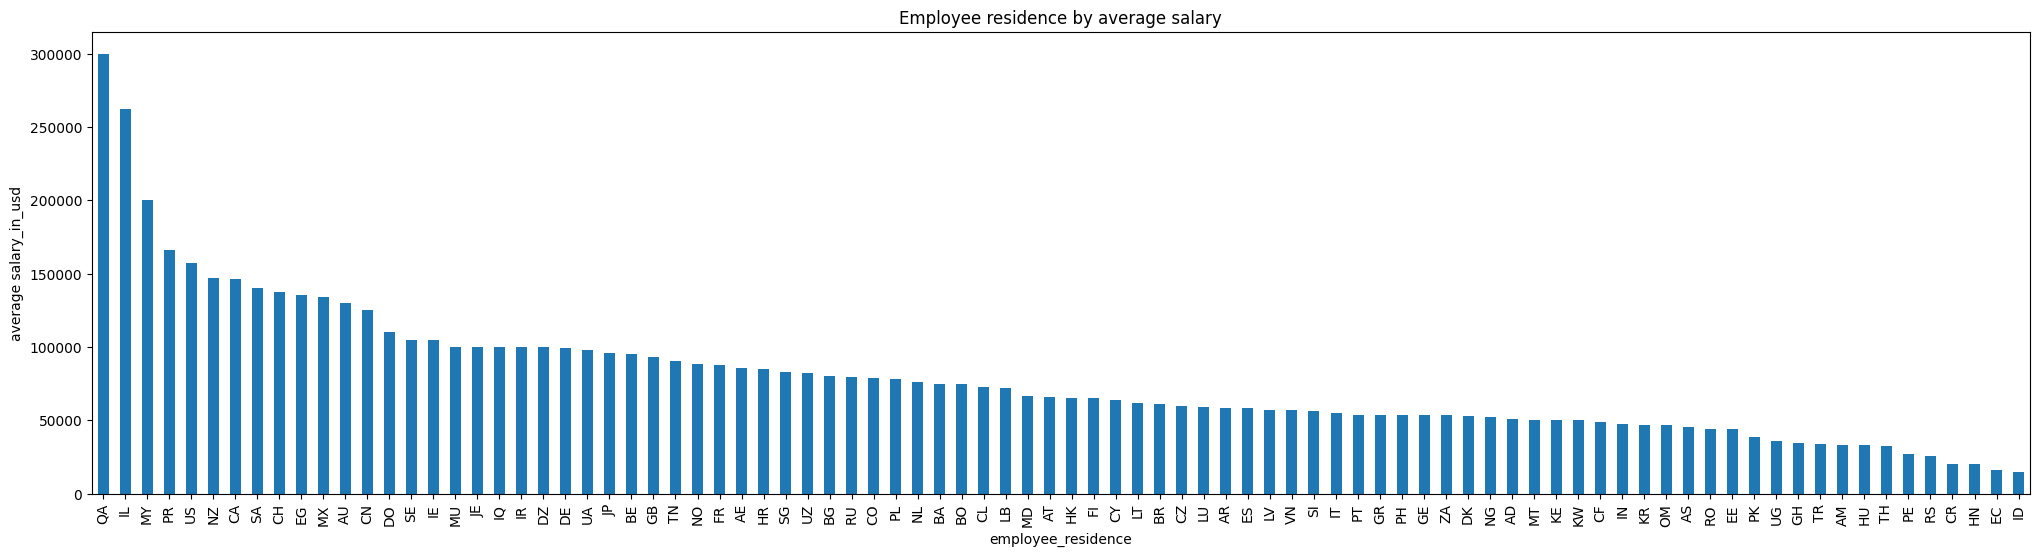

In [ ]:
#plot graph of correlation between employee_residence and salary_in_usd
employee_residence_salary_mean = (
    df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False)
)

employee_residence_salary_mean.plot(kind='bar', figsize=(25,6))
plt.xlabel('employee_residence')
plt.ylabel('average salary_in_usd')
plt.title('Employee residence by average salary')
plt.show()

In [ ]:
# print the percentages of employees with residencies in different countries
print(df['employee_residence'].value_counts(normalize=True) * 100)

employee_residence
US    87.498488
GB     4.149026
CA     2.739809
ES     0.828596
DE     0.592718
        ...    
IQ     0.006048
BG     0.006048
JE     0.006048
RS     0.006048
LU     0.006048
Name: proportion, Length: 88, dtype: float64


Given the strong sample support for countries like **US**, **GB**, **CA**, **ES**, and **DE**, all remaining countries are considered to have insufficient relevance. To prevent the creation of noisy, sparse features during one-hot encoding, these low-support countries are grouped into a unified **'Rest'** category to improve model generalization.

In [ ]:
def employee_residence_categorizer(country: str) -> str:
  c = country.upper()

  if c == "US":
    return "US"
  elif c == "GB":
    return "GB"
  elif c == "CA":
    return "CA"
  elif c == "ES":
    return "ES"
  elif c == "DE":
    return "DE"
  else:
    return "Rest"

df['employee_residence_categorized'] = df['employee_residence'].apply(employee_residence_categorizer)

In [ ]:
print(df['employee_residence_categorized'].value_counts())

employee_residence_categorized
US      14467
Rest      693
GB        686
CA        453
ES        137
DE         98
Name: count, dtype: int64


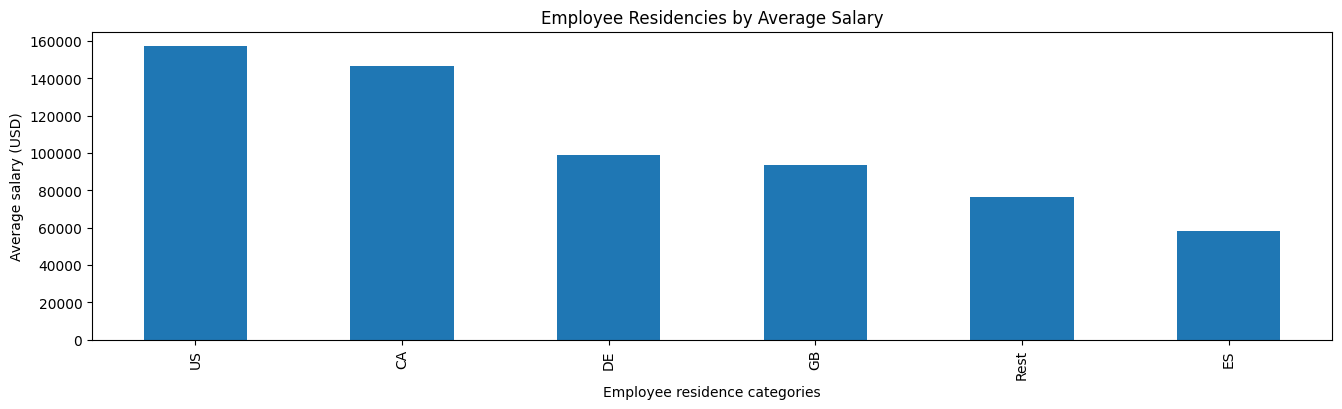

In [ ]:
employee_res_categ_salary_mean = (
    df.groupby("employee_residence_categorized")["salary_in_usd"].mean().sort_values(ascending=False)
)

employee_res_categ_salary_mean.plot(kind='bar', figsize=(16, 4))
plt.xlabel("Employee residence categories")
plt.ylabel("Average salary (USD)")
plt.title("Employee Residencies by Average Salary")
plt.xticks(rotation = 90)
plt.show()

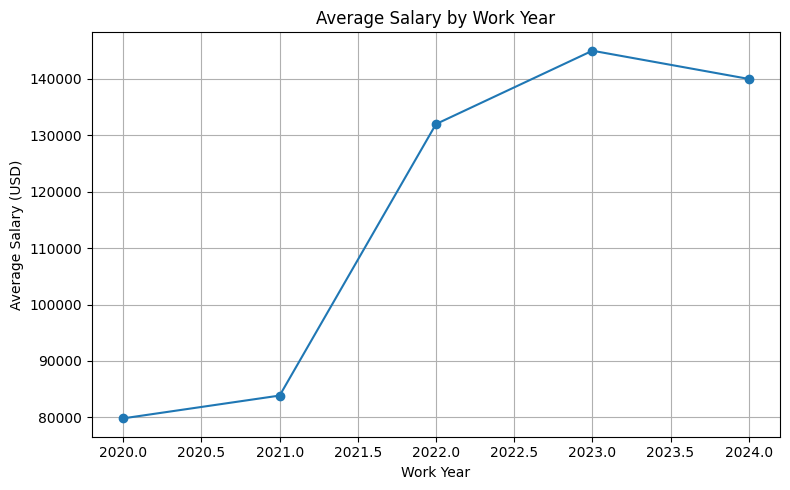

In [ ]:
year_salary_mean = (
    df.groupby("work_year")["salary_in_usd"].median().sort_index()
)

plt.figure(figsize=(8, 5))
year_salary_mean.plot(marker="o")
plt.xlabel("Work Year")
plt.ylabel("Average Salary (USD)")
plt.title("Average Salary by Work Year")
plt.grid(True)
plt.tight_layout()
plt.show()


Treating **'work_year'** as **Categorical** (via OHE) is preferred over continuous. Given its low cardinality, OHE creates distinct, non-linear weights for each year, which is essential to capture economic shifts.

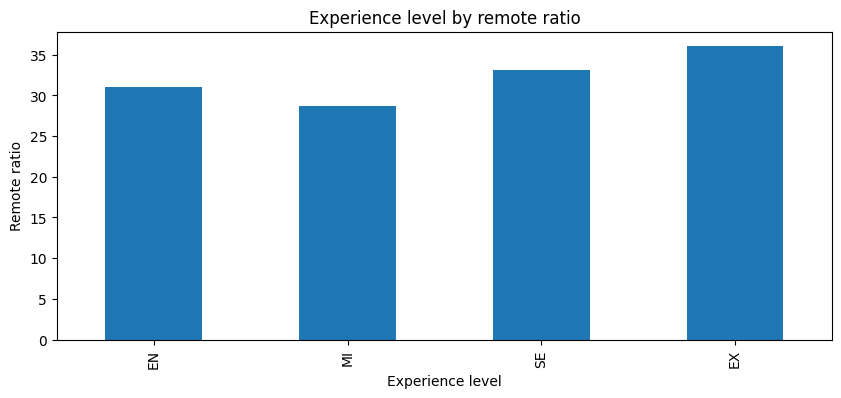

In [ ]:
exp_lvl_remote_ratio = (
    df.groupby('experience_level')['remote_ratio'].mean().reindex(["EN", "MI", "SE", "EX"])
)

exp_lvl_remote_ratio.plot(kind='bar', figsize=(10, 4))
plt.xlabel('Experience level')
plt.ylabel('Remote ratio')
plt.title('Experience level by remote ratio')
plt.show()

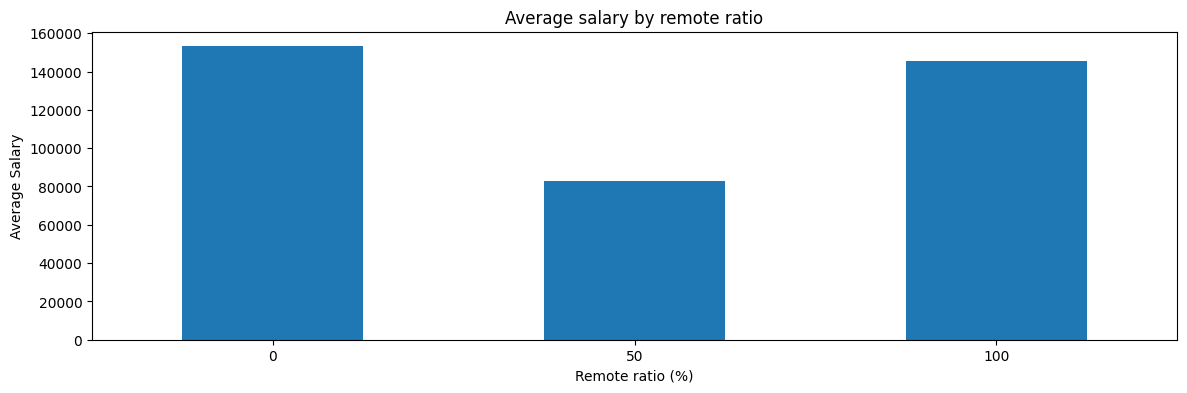

In [ ]:
remote_ratio_by_salary = (
    df.groupby('remote_ratio')['salary_in_usd'].mean().sort_values(ascending=False).reindex([0, 50, 100])
)

remote_ratio_by_salary.plot(kind='bar', figsize=(14, 4))
plt.xlabel('Remote ratio (%)')
plt.ylabel('Average Salary')
plt.title('Average salary by remote ratio')
plt.xticks(rotation=0)
plt.show()

The **'remote_ratio'** feature is retained as a **categorical feature** one-hot encoded. This decision acknowledges the **non-linear relationship** observed between the remote ratio and employee experience level (hybrid 50% differs non-continuously from 0% or 100% remote).

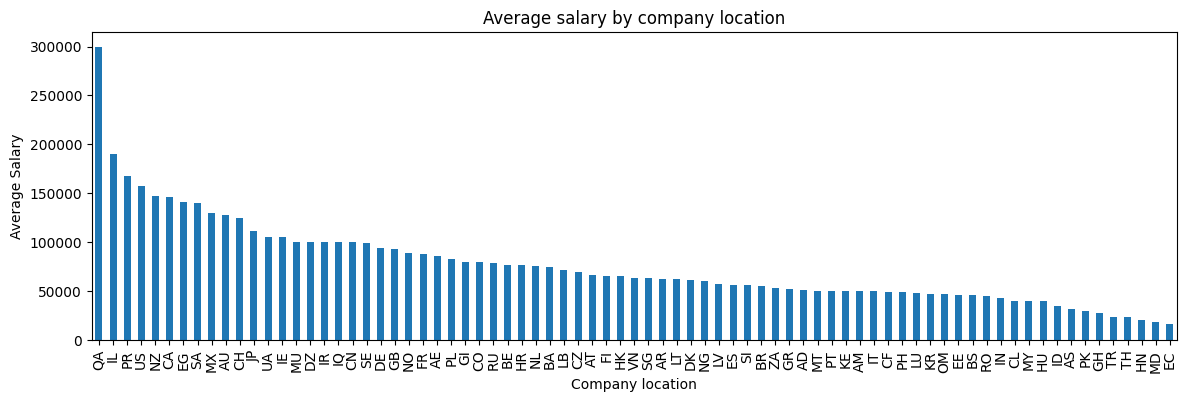

In [ ]:
company_loc_by_salary = (
    df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False)
)

company_loc_by_salary.plot(kind='bar', figsize=(14, 4))
plt.xlabel('Company location')
plt.ylabel('Average Salary')
plt.title('Average salary by company location')
plt.xticks(rotation=90)
plt.show()

Since **employee_residence** and **company_location** show very similar patterns with respect to average salary, they are considered largely redundant. To reduce dimensionality and avoid collinearity, we kept only **employee_residence_categorized** as a one-hot encoded geographic variable.

## Task 3: Preparing the Data 📃

The classification of the dataset is:

* **one-hot encoding:**

    * experience_level
    * job_title_categorized
    * employee_residence_categorized
    * company_size
    * work_year
    * remote_ratio

* **continuous variables:**

    * salary_in_usd

* **not needed variables:**

    * employment_type
    * job_title
    * salary
    * salary_currency
    * employee_residence
    * company_location

In [ ]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size',
       'job_title_categorized', 'employee_residence_categorized'],
      dtype='object')

In [ ]:
one_hot_fields = ["job_title_categorized", "employee_residence_categorized", "company_size", "remote_ratio", "work_year"]

continuous_variables = ["salary_in_usd"]

not_needed = ["employment_type", "job_title", "salary", "salary_currency", "employee_residence", "company_location"]

##Delete the unnecessary columns

In [ ]:
# copy of the initial dataframe
df_backup = df.copy()

# deleting the not needed columns from the dataset
df.drop(not_needed, axis=1, inplace=True)
df.head()

,work_year,experience_level,salary_in_usd,remote_ratio,company_size,job_title_categorized,employee_residence_categorized
0,2024,SE,202730,0,M,AI Engineer,US
1,2024,SE,92118,0,M,AI Engineer,US
2,2024,SE,130500,0,M,Data Engineer,US
3,2024,SE,96000,0,M,Data Engineer,US
4,2024,SE,190000,0,M,Machine Learning Engineer,US


##Encoding categorical features

In [ ]:
target_col = "experience_level"

# One-Hot Encoding
for field in one_hot_fields:
  dummies = pd.get_dummies(df[field], prefix=field, drop_first=False)
  df = pd.concat([df, dummies], axis=1) # concatenates the current one-hot encoded feature to the dataset

# drop the categorical features form the dataframe
df.drop(one_hot_fields, axis=1, inplace=True)

df.head()

,experience_level,salary_in_usd,job_title_categorized_AI Architect,job_title_categorized_AI Developer,job_title_categorized_AI Engineer,job_title_categorized_AI Scientist,job_title_categorized_Analytics Engineer,job_title_categorized_Applied Data Scientist,job_title_categorized_Applied Machine Learning Scientist,job_title_categorized_Applied Scientist,...,company_size_M,company_size_S,remote_ratio_0,remote_ratio_50,remote_ratio_100,work_year_2020,work_year_2021,work_year_2022,work_year_2023,work_year_2024
0,SE,202730,False,False,True,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
1,SE,92118,False,False,True,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
2,SE,130500,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
3,SE,96000,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
4,SE,190000,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True


In [ ]:
# Separate the target and the features
target = df[target_col]
features = df.drop(target_col, axis=1)
features.head()

,salary_in_usd,job_title_categorized_AI Architect,job_title_categorized_AI Developer,job_title_categorized_AI Engineer,job_title_categorized_AI Scientist,job_title_categorized_Analytics Engineer,job_title_categorized_Applied Data Scientist,job_title_categorized_Applied Machine Learning Scientist,job_title_categorized_Applied Scientist,job_title_categorized_BI Analyst,...,company_size_M,company_size_S,remote_ratio_0,remote_ratio_50,remote_ratio_100,work_year_2020,work_year_2021,work_year_2022,work_year_2023,work_year_2024
0,202730,False,False,True,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
1,92118,False,False,True,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
2,130500,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
3,96000,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
4,190000,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True


Data split:

* Train set: 80%
* Test set: 20%

This step performs the train/test split. The key is the stratification by the target variable (**stratify=target**), which ensures the proportion of each experience level (**EN**, **MI**, **SE**, **EX**) is preserved in both the training and test sets.

In [ ]:
from sklearn.model_selection import train_test_split

train_features, test_features, train_target, test_target = train_test_split(features, target, test_size=0.20, random_state=42, stratify=target)

In [ ]:
print("Train features shape: ", train_features.shape)
print("Train targets shape: ", train_target.shape)

print("Test features shape: ", test_features.shape)
print("Test targets shape: ", test_target.shape)

Train features shape:  (13227, 89)
Train targets shape:  (13227,)
Test features shape:  (3307, 89)
Test targets shape:  (3307,)


##Normalization of the data

The **StandardScaler** is applied to all continuous features (represented by field). The crucial step is applying ***fit_transform*** **only to the training set** (train_features). The test set (test_features) is then ***transformed*** using the same parameters (mean and standard deviation) derived from the training data.  This process is essential to **prevent data leakage**, ensuring the model remains unaware of the test set's distribution during training.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# A dictionary to store each scaler to reuse it
scalers = {}

for field in continuous_variables:

  # Fit only on the TRAIN column (2D)
  train_features[field] = scaler.fit_transform(train_features[[field]])

  # Transform TEST using the fitted scaler
  test_features[field] = scaler.transform(test_features[[field]])

  # Save the scaler to reverse the transformation later
  scalers[field] = scaler

train_features.head()

,salary_in_usd,job_title_categorized_AI Architect,job_title_categorized_AI Developer,job_title_categorized_AI Engineer,job_title_categorized_AI Scientist,job_title_categorized_Analytics Engineer,job_title_categorized_Applied Data Scientist,job_title_categorized_Applied Machine Learning Scientist,job_title_categorized_Applied Scientist,job_title_categorized_BI Analyst,...,company_size_M,company_size_S,remote_ratio_0,remote_ratio_50,remote_ratio_100,work_year_2020,work_year_2021,work_year_2022,work_year_2023,work_year_2024
3028,-1.316242,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
14212,0.482065,False,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
12302,0.185399,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
8483,-1.029099,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
6351,-0.164740,False,False,False,False,False,False,False,True,False,...,True,False,True,False,False,False,False,False,True,False


## Task 3: Define the SVM 📃

In [ ]:
from sklearn.svm import SVC

## Task 4: Train 📃

GridSearchCV is used to systematically search the defined param_grid (which tests 3 values of **C** with the **RBF** kernel) to find the optimal SVM settings. By setting **cv=5**, the grid evaluates $3 \times 1 \times 1 = 3$ models, each trained across **5-fold cross-validation**. The resulting **grid.best_params_** provides the most effective parameter combination for maximizing classification accuracy.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [1, 5, 8, 10, 15],
    "gamma": ["scale"],
    "kernel": ["rbf"]
}

# Only the RBF kernel is included in the grid.
# This decision is justified by the dataset's clear need for a non-linear classifier due to the complex feature interactions and the high-dimensional
# space created by the One-Hot Encoded variables.
# A linear kernel cannot effectively separate the "experience_level" classes in this configuration.

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1 # enables parallel processing across all available CPU cores
)

grid.fit(train_features, train_target)
print("The best parameters found are:", grid.best_params_)
print("\nThe best accuracy achieved is:", grid.best_score_)

The best parameters found are: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}

The best accuracy achieved is: 0.7075676092743335


##Task 5: Test 📃

In [ ]:
# Select the best estimator found with GridSearchCV and predict the test_target
model = grid.best_estimator_
test_target_prediction = model.predict(test_features)

## Task 6: Show results and compare different values of C 📃

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # used for confusion_matrix heatmap

              precision    recall  f1-score   support

          EN       0.53      0.37      0.44       265
          EX       0.85      0.28      0.42       100
          MI       0.61      0.30      0.40       808
          SE       0.74      0.93      0.82      2134

    accuracy                           0.71      3307
   macro avg       0.68      0.47      0.52      3307
weighted avg       0.69      0.71      0.68      3307



Text(0.5, 1.0, 'confusion matrix of the test set')

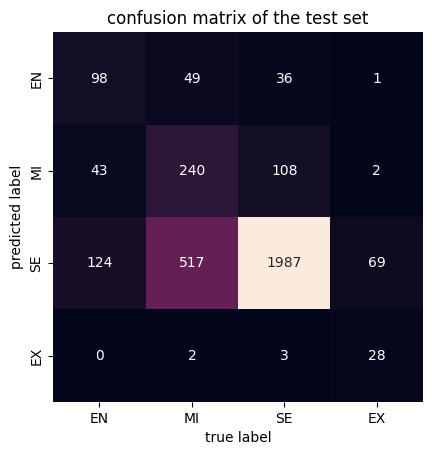

In [ ]:
print(classification_report(test_target, test_target_prediction))

class_names = ['EN', 'MI', 'SE', 'EX']
mat = confusion_matrix(test_target, test_target_prediction, labels=class_names)

sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.title('confusion matrix of the test set')

##Results and comparisons:

1. Interpretation of best hyperparameters (C and $\gamma$)

    * The optimal parameters found by **GridSearchCV** are **C=5**, **gamma='scale'**, and **kernel='rbf'**.

    * Regularization parameter (**C=5**): The relatively high value of **C** indicates the model prioritizes a stricter classification boundary over allowing margin errors. This low-bias approach suggests that the SVM is effectively utilizing the separation provided by the discriminative features, such as the **salary_in_usd** and the categorized **job_title**.

    * Gamma parameter (**gamma='scale'**): By using the **'scale'** setting for gamma, the SVM automatically calculates a value based on the number of features and the variance of the data. This choice allows the influence of a single training example to be dynamically adapted to the structure of the high-dimensional feature space. The scaled gamma provides a stable balance in the RBF kernel's influence, preventing the decision boundary from becoming either **too loose** (high bias) or **too tightly curved** (high variance/overfitting to noise).

2. Analysis of classification report and model limitations

    * The overall accuracy of **70.75%** reflects the model's performance on the dataset as a whole, but the classification report reveals severe limitations driven by class imbalance. The **Senior** class, which dominates the dataset, is classified with excellent recall (**0.93**) and strong precision (**0.74**). The model is highly effective at identifying true Senior roles, demonstrating that the learned decision boundary is well-defined in this high-support region.

    * The minority classes (**EN**, **EX**, **MI**) suffer significantly due to their low number of samples. The most severe outcome is seen in the Executive class, which has a very low recall (**0.28**), meaning the model correctly identifies less than **30%** of all actual Executive roles.

3. Interpretation of the confusion matrix

    * The confusion matrix would visually confirm that the **SE** class acts as an absorbing state. Misclassified samples from **EN**, **MI**, and **EX** are predominantly assigned to the **SE** class. This occurs because the SVM decision boundary is optimized primarily to minimize errors for the vast **SE** class, drawing the boundary too close to the underrepresented classes.


To visualize whether the model is suffering from high bias (**underfitting**) or high variance (**overfitting**), we can use a **Learning Curve**. This plots the training and validation scores against a varying number of training samples.

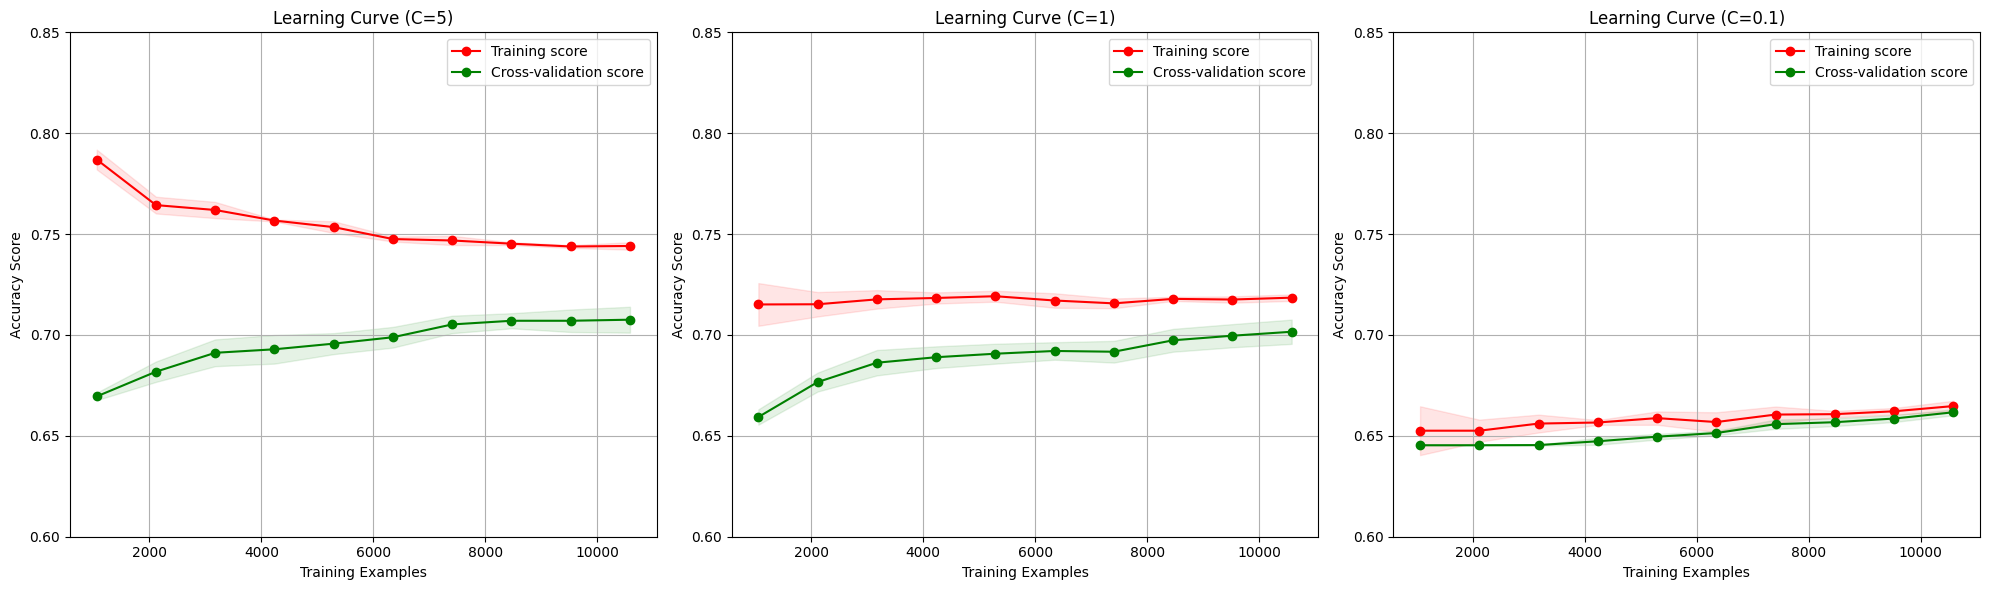

In [ ]:
from sklearn.model_selection import learning_curve

def plot_comparative_learning_curves(X, y):
    c_values = [5, 1, 0.1]
    plt.figure(figsize=(20, 6))

    for i, c_val in enumerate(c_values):
        model = SVC(C=c_val, gamma='scale', kernel='rbf')

        # calculate learning curves
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=5, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='accuracy'
        )

        # statistical calculations
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.subplot(1, 3, i + 1)

        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

        plt.title(f"Learning Curve (C={c_val})")
        plt.xlabel("Training Examples")
        plt.ylabel("Accuracy Score")
        plt.ylim(0.60, 0.85)
        plt.legend(loc="best")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_comparative_learning_curves(train_features, train_target)

##Interpretations of the Learning Curve (C=5.0):

1. The Training score:
    * It starts high (close to 0.80) and dips slightly as the number of training samples increases (more samples implies more constraints).
    * Interpretation: The model is "memorizing" the training data easily, especially the dominant SE class.
2. The Cross-Validation score:
    * It starts much lower and rises as more data is added, eventually becoming constant at 0.71 accuracy.
    * Interpretation: This is the model's actual ability to generalize. The fact that it becomes constant suggests that adding more of the same kind of data won't improve accuracy further.
3. The gap between the lines:
    * There is a noticeable gap between the lines at the far right of the plot, which indicates that the model has **High Variance** (**Overfitting**). The **RBF** kernel and **C=5** are still making the model a bit too specialized for the training data. Because of the class imbalance, it is likely overfitting to the noise of the dominant SE class while failing to capture the patterns of the minority classes.

##Conclusion based on the three values of C:

  * The experiment confirms that **C=1** is the best choice for a reliable model. By allowing more margine errors, the model stopped chasing noise patterns. The training and validation lines converged, meaning that the model has a predictable behaviour (better generalization).
  * With **C=5** the model tries to capture every detail of the training data. While this is the choice that maximizes the testing accuracy, the gap proves the model is overrelying on specific training samples (it has low bias but high variance).
  * For **C=0.1** the penalty for errors is so low that the SVM is choosing a boundary that is too smooth to capture the actual patterns in the data. Even though the gap is gone, the accuracy is poor because the model is underfitting (it has high bias but low variance).